1. Bentuk model regresi linear berganda dari dataset yang diberikan.
2. Interpretasikan setiap koefisien dalam model.
3. Hitung dan interpretasikan nilai R² dan RMSE.
4. Lakukan uji signifikansi (uji t dan uji F).
5. Deteksi adanya multikolinieritas, jelaskan dampak dan solusinya.
6. Deteksi heteroskedastisitas, jelaskan dampak dan solusinya.
7. Deteksi autokorelasi, jelaskan dampak dan solusinya.
8. Lakukan transformasi data jika diperlukan dan bandingkan hasilnya.
9. Lakukan seleksi model untuk mendapatkan model terbaik.
10. Lakukan validasi model (train-test split) dan evaluasi hasilnya.


In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
import scipy.stats as stats

In [30]:

import pandas as pd
df = pd.read_csv("/content/data uas.csv")
y=df["jumlah_hotspot"]
X=df[['curah_hujan', 'suhu', 'kelembapan', 'kecepatan_angin', 'luas_gambut', 'aktivitas_manusia']]

print(df.head())

   waktu  jumlah_hotspot  curah_hujan       suhu  kelembapan  kecepatan_angin  \
0      0      164.493813   256.356966  30.871222   69.072851         6.591475   
1      1      333.178771   141.736253  33.299111   65.186703         5.662623   
2      2      284.459670   287.661481  27.040774   72.198344         4.599631   
3      3      230.267885   208.732576  32.260659   66.270165         5.735192   
4      4      296.796170   158.752269  31.735273   67.557370         5.335588   

   luas_gambut  aktivitas_manusia  
0  3261.593123           0.415596  
1  6652.634048           0.262379  
2  5193.499502           0.426913  
3  5423.093185           0.534826  
4  2279.831324          -0.447486  


### **PEMBERSIHAN DATA**

In [31]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   waktu              200 non-null    int64  
 1   jumlah_hotspot     200 non-null    float64
 2   curah_hujan        200 non-null    float64
 3   suhu               200 non-null    float64
 4   kelembapan         200 non-null    float64
 5   kecepatan_angin    200 non-null    float64
 6   luas_gambut        200 non-null    float64
 7   aktivitas_manusia  200 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 12.6 KB
None


In [32]:
print(df.duplicated())

0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool


In [33]:
# Jumlah outlier
print("Jumlah outlier untuk tiap variabel:")
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5* IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"  {col}: {len(outliers)}")

Jumlah outlier untuk tiap variabel:
  waktu: 0
  jumlah_hotspot: 4
  curah_hujan: 1
  suhu: 2
  kelembapan: 2
  kecepatan_angin: 2
  luas_gambut: 3
  aktivitas_manusia: 0


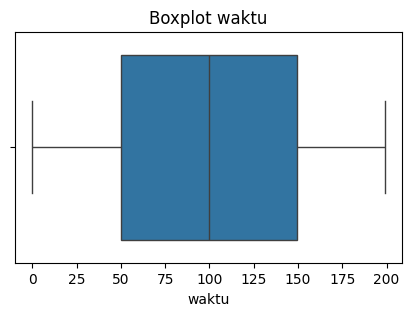

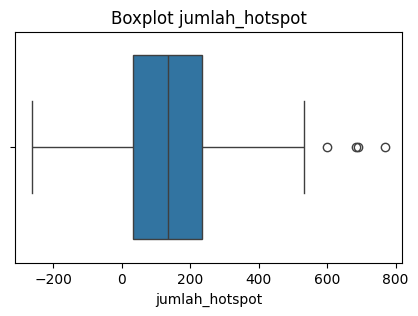

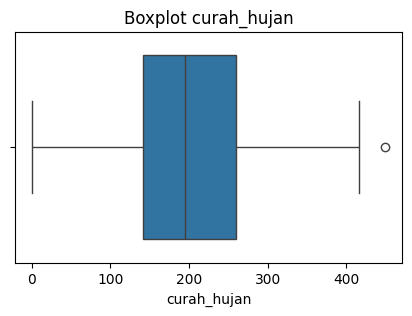

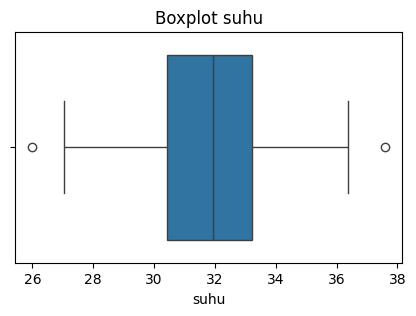

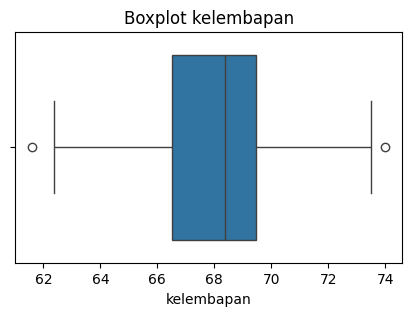

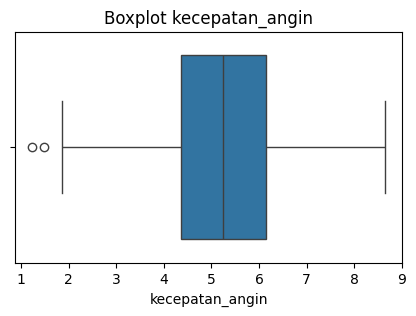

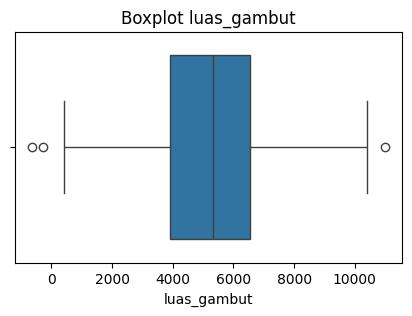

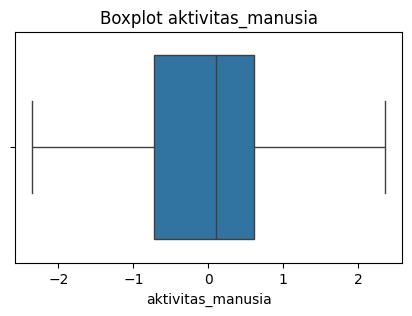

In [34]:
for col in df.columns:
  plt.figure(figsize=(5,3))
  sns.boxplot(x=df[col])
  plt.title(f'Boxplot {col}')
  plt.show()

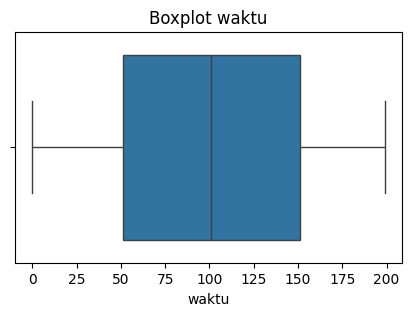

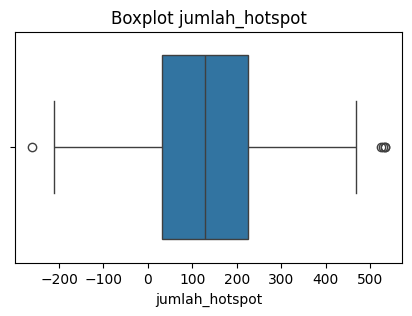

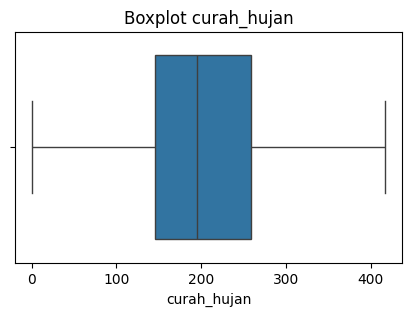

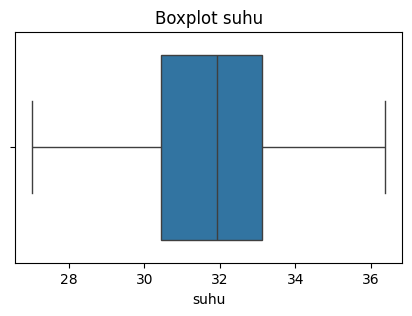

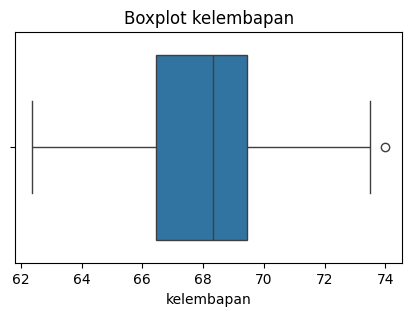

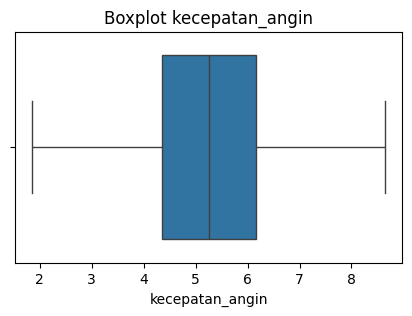

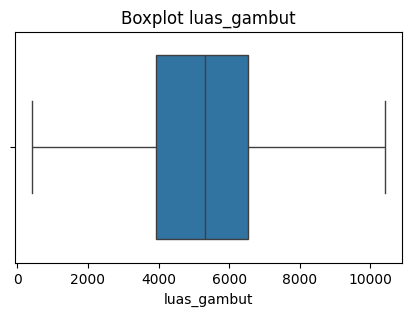

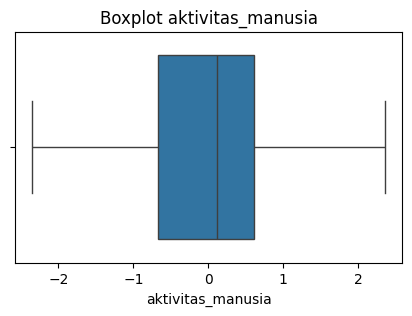

In [35]:
df_clean = df.copy()

for col in df_clean.select_dtypes(include='number').columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]
for col in df_clean.columns:
  plt.figure(figsize=(5,3))
  sns.boxplot(x=df_clean[col])
  plt.title(f'Boxplot {col}')
  plt.show()

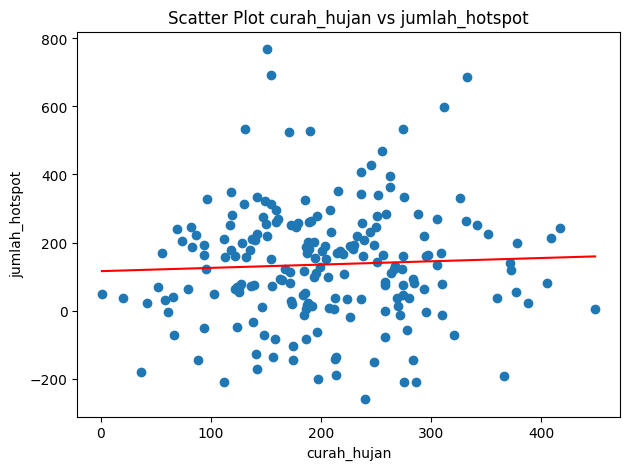

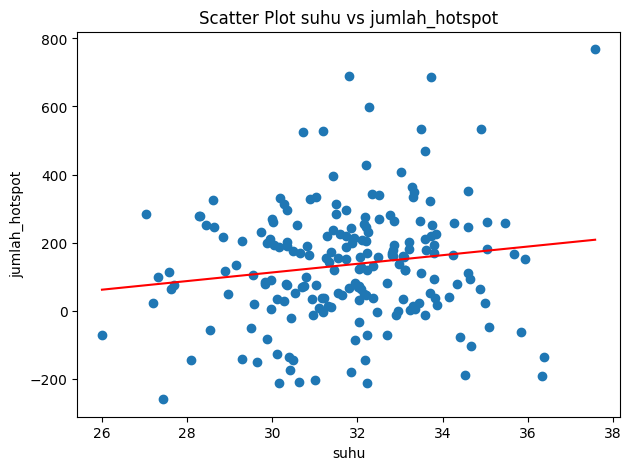

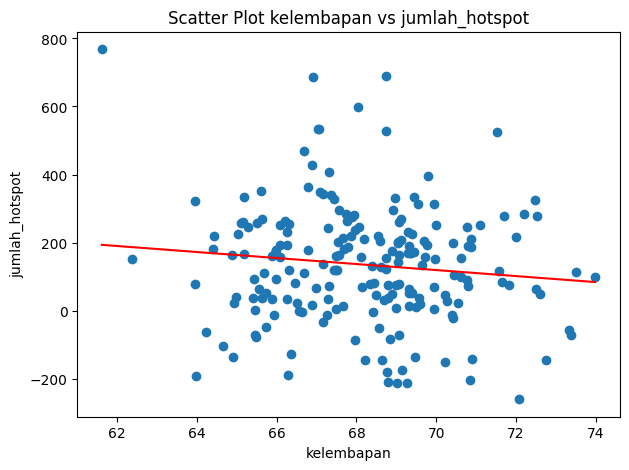

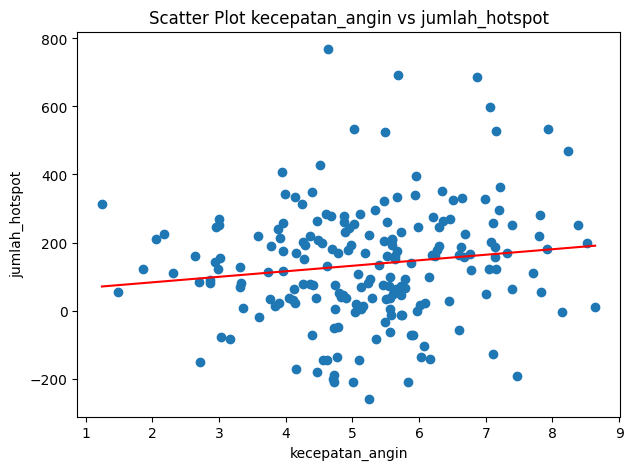

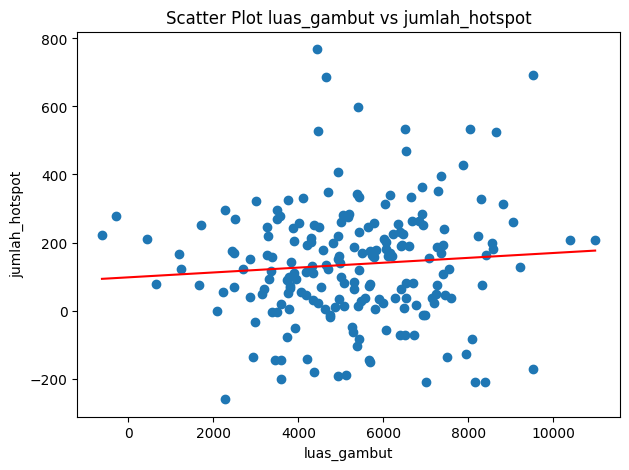

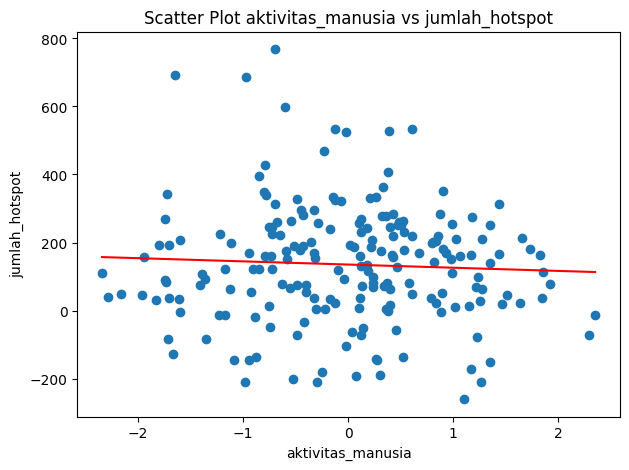

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

X_ols = sm.add_constant(X)
y_ols_series = df['jumlah_hotspot']
model = sm.OLS(y_ols_series, X_ols).fit()

# SCATTERPLOT DENGAN GARIS REGRESI

for col_name in X.columns:
    plt.figure(figsize=(7, 5))
    plt.scatter(df[col_name], y_ols_series)
    slope_linregress, intercept_linregress, _, _, _ = linregress(
        df[col_name], y_ols_series
    )

    # Membuat garis regresi
    X_line = np.linspace(df[col_name].min(), df[col_name].max(), 100)
    Y_line = intercept_linregress + slope_linregress * X_line

    # Plot garis regresi
    plt.plot(X_line, Y_line, color='red')

    plt.xlabel(col_name)
    plt.ylabel('jumlah_hotspot')
    plt.title(f"Scatter Plot {col_name} vs jumlah_hotspot")
    plt.show()



# **1.Bentuk model regresi linear berganda dari dataset yang diberikan.**

In [37]:


y=df["jumlah_hotspot"]
X=df[['curah_hujan', 'suhu', 'kelembapan', 'kecepatan_angin', 'luas_gambut', 'aktivitas_manusia']]

import statsmodels.api as sm
X_const = sm.add_constant(X)

# Membentuk model regresi linear berganda
model = sm.OLS(y, X_const).fit()
print(model.summary())

params = model.params

# Intercept
intercept = params['const']

print("\nPersamaan Regresi Linear Berganda:")
equation = f"Jumlah hotspot = {intercept:.4f}"

for var in X.columns:
    coef = params[var]
    if coef >= 0:
        equation += f" + {coef:.4f}({var})"
    else:
        equation += f" - {abs(coef):.4f}({var})"

print(equation)

                            OLS Regression Results                            
Dep. Variable:         jumlah_hotspot   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     1.496
Date:                Wed, 27 May 2026   Prob (F-statistic):              0.182
Time:                        13:55:39   Log-Likelihood:                -1309.8
No. Observations:                 200   AIC:                             2634.
Df Residuals:                     193   BIC:                             2657.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              -663.2339   1171.78

# **2.Interpretasikan setiap koefisien dalam model.**

In [38]:
# ---------------------------
# Interpretasi Intercept
# ---------------------------
print(f"\n1. Intercept (β0 = {round(intercept, 4)}):")
print(
    f"   Nilai Y ketika seluruh variabel independen bernilai 0 "
    f"adalah {round(intercept, 4)}.\n"
)

# ---------------------------
# Interpretasi Semua Koefisien
# ---------------------------
for i, var in enumerate(params.index):
    if var != 'const':
        coef = round(params[var], 4)

        print(f"{i + 1}. Koefisien {var} (β = {coef}):")

        if coef > 0:
            print(
                f"   Setiap kenaikan 1 satuan pada variabel {var}, "
                f"dengan variabel independen lainnya dianggap konstan, "
                f"jumlah hotspot akan meningkatkan nilai Y sebesar {coef} satuan.\n"
            )
        else:
            print(
                f"   Setiap kenaikan 1 satuan pada variabel {var}, "
                f"dengan variabel independen lainnya dianggap konstan, "
                f" jumlah hotspot akan menurunkan nilai Y sebesar {abs(coef)} satuan.\n"
            )


1. Intercept (β0 = -663.2339):
   Nilai Y ketika seluruh variabel independen bernilai 0 adalah -663.2339.

2. Koefisien curah_hujan (β = 0.056):
   Setiap kenaikan 1 satuan pada variabel curah_hujan, dengan variabel independen lainnya dianggap konstan, jumlah hotspot akan meningkatkan nilai Y sebesar 0.056 satuan.

3. Koefisien suhu (β = 14.2047):
   Setiap kenaikan 1 satuan pada variabel suhu, dengan variabel independen lainnya dianggap konstan, jumlah hotspot akan meningkatkan nilai Y sebesar 14.2047 satuan.

4. Koefisien kelembapan (β = 3.3362):
   Setiap kenaikan 1 satuan pada variabel kelembapan, dengan variabel independen lainnya dianggap konstan, jumlah hotspot akan meningkatkan nilai Y sebesar 3.3362 satuan.

5. Koefisien kecepatan_angin (β = 14.5248):
   Setiap kenaikan 1 satuan pada variabel kecepatan_angin, dengan variabel independen lainnya dianggap konstan, jumlah hotspot akan meningkatkan nilai Y sebesar 14.5248 satuan.

6. Koefisien luas_gambut (β = 0.006):
   Setiap ke

# **3. Hitung dan interpretasikan nilai R² dan RMSE**

In [39]:

from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_const)

r_squared = model.rsquared
rmse = np.sqrt(mean_squared_error(y, y_pred))


print("R²              =", round(r_squared, 4))
print("RMSE            =", round(rmse, 4))

print("\nINTERPRETASI:")

print(
    f"- Nilai R² = {r_squared:.4f} berarti "
    f"{r_squared*100:.2f}% variasi pada variabel dependen "
    f"dapat dijelaskan oleh seluruh variabel independen dalam model."
)


print(
    f"- Nilai RMSE = {rmse:.4f} menunjukkan bahwa rata-rata "
    f"kesalahan prediksi model adalah sekitar {rmse:.4f} "
    f"satuan dari variabel dependen."
)

R²              = 0.0444
RMSE            = 169.0163

INTERPRETASI:
- Nilai R² = 0.0444 berarti 4.44% variasi pada variabel dependen dapat dijelaskan oleh seluruh variabel independen dalam model.
- Nilai RMSE = 169.0163 menunjukkan bahwa rata-rata kesalahan prediksi model adalah sekitar 169.0163 satuan dari variabel dependen.


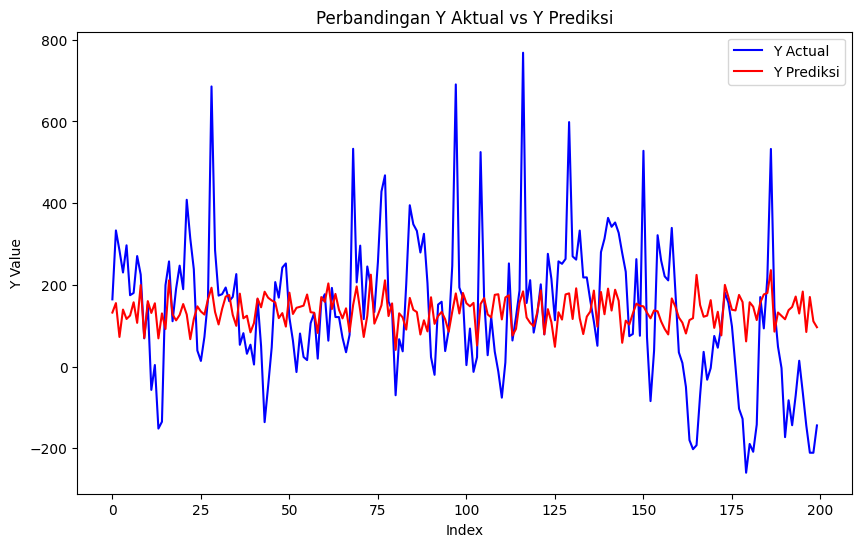

In [40]:
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import linregress

# Prediksi
y_pred = model.predict(X_ols)

# Evaluasi
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

# Perbandingan
hasil = pd.DataFrame({
    'Y_aktual': y,
    'Y_prediksi': y_pred,
    'Error': y - y_pred
})


# Grafik perbandingan
plt.figure(figsize=(10, 6))

plt.plot(y.values, label="Y Actual", color="blue")
plt.plot(y_pred.values, label="Y Prediksi", color="red")

plt.xlabel("Index")
plt.ylabel("Y Value")
plt.title("Perbandingan Y Aktual vs Y Prediksi")
plt.legend()
plt.show()

# **4.Lakukan uji signifikansi (uji t dan uji F)**

In [41]:
# Uji t (Parsial)
print("Nilai t-statistik:")
print(model.tvalues)

print("\nP-value:")
print(model.pvalues)

# Uji F (Simultan)
print("Nilai F-statistik:", model.fvalue)
print("P-value uji F:", model.f_pvalue)

# Keputusan Signifikansi
alpha = 0.05

print("\nKesimpulan Uji signifikan:")
for var, pval in model.pvalues.items():
    if pval < alpha:
        print(f"{var} signifikan (p-value = {pval})")
    else:
        print(f"{var} TIDAK signifikan (p-value = {pval})")

Nilai t-statistik:
const               -0.566002
curah_hujan          0.380944
suhu                 1.085327
kelembapan           0.286535
kecepatan_angin      1.695246
luas_gambut          0.961525
aktivitas_manusia   -0.624400
dtype: float64

P-value:
const                0.572050
curah_hujan          0.703664
suhu                 0.279131
kelembapan           0.774776
kecepatan_angin      0.091642
luas_gambut          0.337492
aktivitas_manusia    0.533102
dtype: float64
Nilai F-statistik: 1.4955522272381012
P-value uji F: 0.1815361324030333

Kesimpulan Uji signifikan:
const TIDAK signifikan (p-value = 0.5720499109257191)
curah_hujan TIDAK signifikan (p-value = 0.7036637906968529)
suhu TIDAK signifikan (p-value = 0.2791307062050943)
kelembapan TIDAK signifikan (p-value = 0.7747761185219962)
kecepatan_angin TIDAK signifikan (p-value = 0.09164150788337211)
luas_gambut TIDAK signifikan (p-value = 0.3374915170952085)
aktivitas_manusia TIDAK signifikan (p-value = 0.5331021322163656)


# **UJI ASUMSI KLASIK**

**UJI NORMALITAS**


--- Uji Normalitas (Shapiro-Wilk Test) ---
Statistik Uji: 0.986, P-value: 0.050
Keputusan: Tolak H0. Residual tidak terdistribusi normal.


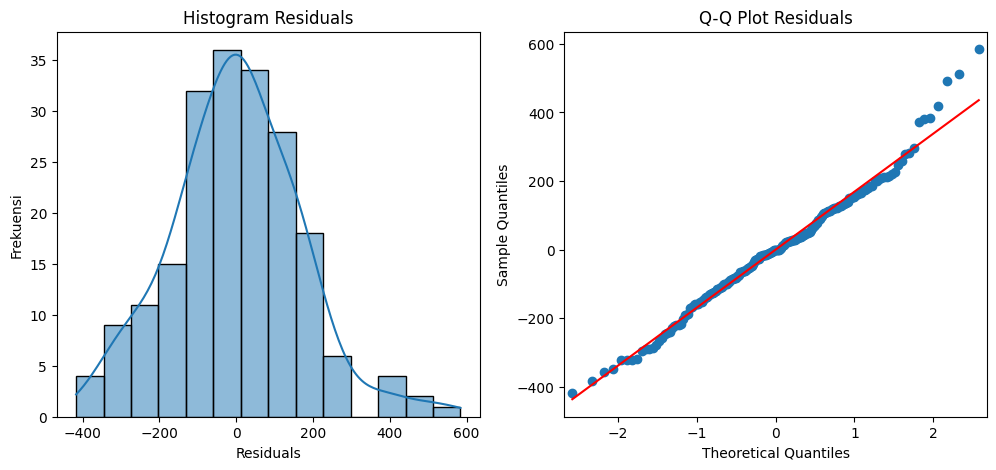

In [42]:
from scipy.stats import shapiro
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Calculate residuals
residuals = model.resid

print("\n--- Uji Normalitas (Shapiro-Wilk Test) ---")
stat, p = shapiro(residuals)
print(f'Statistik Uji: {stat:.3f}, P-value: {p:.3f}')

if p > 0.05:
    print('Keputusan: Gagal menolak H0. Residual terdistribusi normal.')
else:
    print('Keputusan: Tolak H0. Residual tidak terdistribusi normal.')

# Plot
fig, ax = plt.subplots(1,2, figsize=(12,5))

# Histogram
sns.histplot(residuals, kde=True, ax=ax[0])
ax[0].set_title('Histogram Residuals')
ax[0].set_xlabel('Residuals')
ax[0].set_ylabel('Frekuensi')

# QQ Plot
sm.qqplot(residuals, line='s', ax=ax[1])
ax[1].set_title('Q-Q Plot Residuals')

plt.show()

In [43]:
import numpy as np
import statsmodels.api as sm
from scipy.stats import shapiro


# Transformasi sqrt
y_transformasi = np.sqrt(df["jumlah_hotspot"] - df["jumlah_hotspot"].min() + 1)

# Variabel X
X = df[['curah_hujan', 'suhu', 'kelembapan',
        'kecepatan_angin', 'luas_gambut',
        'aktivitas_manusia']]

# Tambah konstanta
X_const = sm.add_constant(X)

# Model regresi
model = sm.RLM(y_transformasi, X_const).fit()

# Residual
residuals = model.resid

# Uji normalitas

print("\n--- Uji Normalitas (Shapiro-Wilk Test) ---")
stat, p = shapiro(residuals)
print(f'Statistik Uji: {stat:.3f}, P-value: {p:.3f}')


if p > 0.05:
    print("Residual berdistribusi normal")
else:
    print("Residual tidak berdistribusi normal")


--- Uji Normalitas (Shapiro-Wilk Test) ---
Statistik Uji: 0.965, P-value: 0.000
Residual tidak berdistribusi normal


# **5.Deteksi adanya multikolinieritas, jelaskan dampak dan solusinya**

Variance Inflation Factor (VIF) adalah metode statistik yang digunakan untuk mendeteksi multikolinearitas(memiliki hubungan yang sangat kuat) dalam analisis regresi linear. Multikolinearitas terjadi ketika dua atau lebih variabel independen dalam model regresi memiliki korelasi(hubungan antara dua variabel) yang sangat tinggi, yang dapat menyebabkan masalah dalam interpretasi hasil regresi

**Interpretasi Hasil :**


*   VIF < 5 → Tidak ada masalah multikolinearitas
*   5 ≤ VIF ≤ 10 → Ada indikasi multikolinearitas, perlu diperiksa lebih lanjut
*   VIF > 10 → Multikolinearitas tinggi, sebaiknya diperbaiki (misalnya, dengan menghapus variabel yang berkorelasi tinggi).



In [44]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Menghitung VIF menggunakan X_ols
vif_data = pd.DataFrame()
vif_data["Variabel"] = X_ols.columns
vif_data["VIF"] = [variance_inflation_factor(X_ols.values, i) for i in range(X_ols.shape[1])]

print(vif_data)

            Variabel          VIF
0              const  9276.786536
1        curah_hujan     1.028837
2               suhu     4.630849
3         kelembapan     4.545701
4    kecepatan_angin     1.014076
5        luas_gambut     1.015622
6  aktivitas_manusia     1.009268


Model regresi tidak mengalami multikolinearitas yang serius karena seluruh variabel independen memiliki nilai VIF < 10. Namun, variabel suhu dan kelembapan menunjukkan korelasi yang cukup tinggi dibanding variabel lainnya, meskipun masih dalam batas yang dapat diterima.


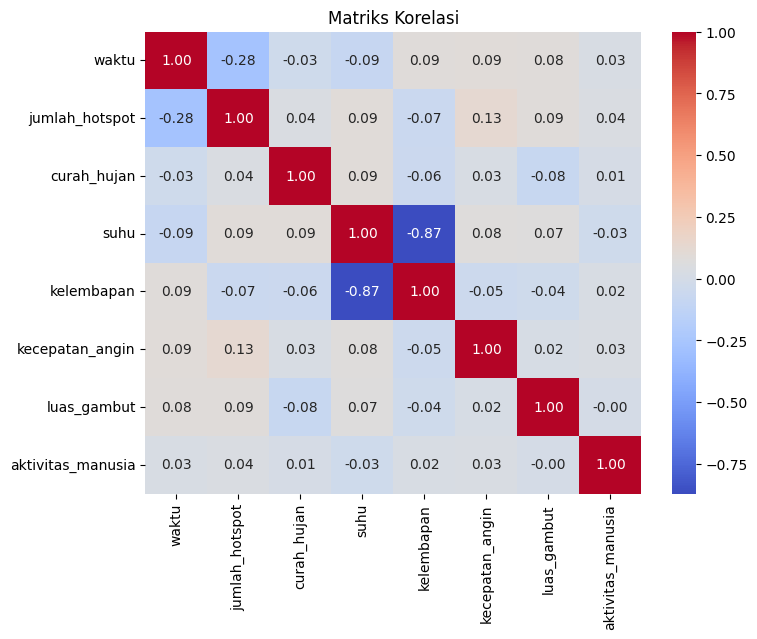

In [45]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriks Korelasi")
plt.show()

# **6.Deteksi heteroskedastisitas, jelaskan dampak dan solusinya**


--- Uji Heteroskedastisitas (Breusch-Pagan Test) ---
LM Stat : 1.7347196458246783
p-value : 0.9424094986232344
Hipotesis Nol (H0): Tidak ada heteroskedastisitas.
Keputusan: Terima H0. Tidak ada heteroskedastisitas (homoskedastisitas).


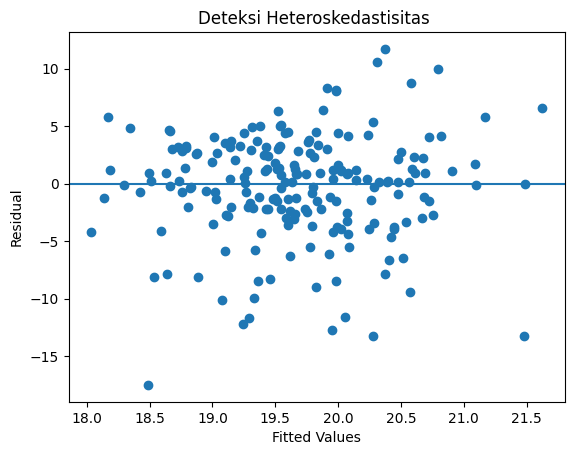

In [46]:
import matplotlib.pyplot as plt
from statsmodels.stats.api import het_breuschpagan

fitted_values = model.fittedvalues

print("\n--- Uji Heteroskedastisitas (Breusch-Pagan Test) ---")
bp_test = het_breuschpagan(model.resid, model.model.exog)
print("LM Stat :", bp_test[0])
print("p-value :", bp_test[1])


print("Hipotesis Nol (H0): Tidak ada heteroskedastisitas.")

if bp_test[1] > 0.05:
    print('Keputusan: Terima H0. Tidak ada heteroskedastisitas (homoskedastisitas).')
else:
    print('Keputusan: Tolak H0. Terdapat heteroskedastisitas.')


plt.figure()
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0)

plt.title('Deteksi Heteroskedastisitas ')
plt.xlabel('Fitted Values')
plt.ylabel('Residual')

plt.show()

Berdasarkan uji Breusch–Pagan dengan p-value sebesar 0,1020 (> 0,05), model regresi tidak mengalami heteroskedastisitas. Hal ini menunjukkan bahwa varians residual bersifat konstan sehingga asumsi homoskedastisitas pada regresi linear telah terpenuhi.

# **7.Deteksi autokorelasi, jelaskan dampak dan solusinya**



=== UJI AUTOKORELASI (DURBIN-WATSON) ===
Nilai Durbin-Watson = 0.6489

Kesimpulan: Terdapat indikasi autokorelasi positif.



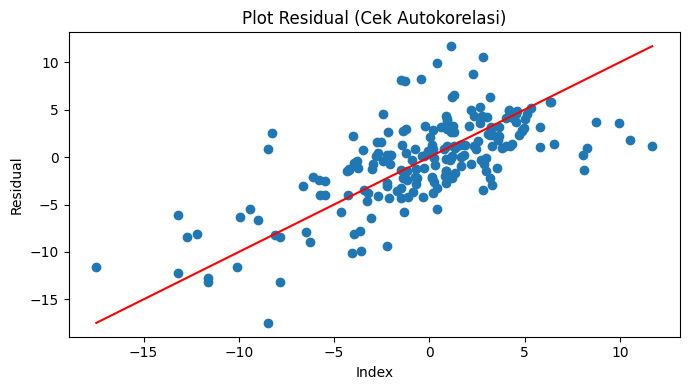

In [47]:
# ==========================================================
# UJI AUTOKORELASI + SCATTER PLOT RESIDUAL
# ==========================================================

import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf


# Ambil residual dari model
residual = model.resid
dw = durbin_watson(model.resid)

print("=== UJI AUTOKORELASI (DURBIN-WATSON) ===")
print(f"Nilai Durbin-Watson = {dw:.4f}\n")

# Interpretasi otomatis
if 1.5 <= dw <= 2.5:
    print("Kesimpulan: Tidak terdapat autokorelasi pada residual model.\n")
elif dw < 1.5:
    print("Kesimpulan: Terdapat indikasi autokorelasi positif.\n")
else:
    print("Kesimpulan: Terdapat indikasi autokorelasi negatif.\n")


# Plot residual
plt.figure(figsize=(7,4))
pd.plotting.lag_plot(pd.Series(residual))
x = np.linspace(min(residual), max(residual), 100)
plt.plot(x, x, linestyle='-', color='red')
plt.title("Plot Residual (Cek Autokorelasi)")
plt.xlabel("Index")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()


=== MODEL AWAL ===
                            OLS Regression Results                            
Dep. Variable:         jumlah_hotspot   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     1.496
Date:                Wed, 27 May 2026   Prob (F-statistic):              0.182
Time:                        13:55:40   Log-Likelihood:                -1309.8
No. Observations:                 200   AIC:                             2634.
Df Residuals:                     193   BIC:                             2657.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              

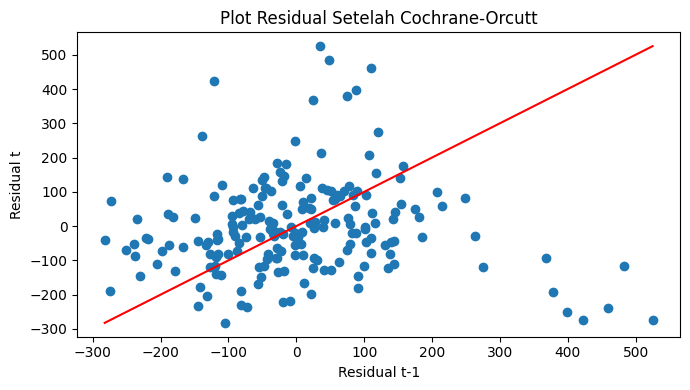

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson


# =========================
# MODEL AWAL
# =========================
y=df["jumlah_hotspot"]
X=df[['curah_hujan', 'suhu', 'kelembapan', 'kecepatan_angin', 'luas_gambut', 'aktivitas_manusia']]

import statsmodels.api as sm
X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()

print("=== MODEL AWAL ===")
print(model.summary())

# =========================
# DURBIN-WATSON AWAL
# =========================

dw_awal = durbin_watson(model.resid)

print("\nDurbin-Watson Awal:", dw_awal)

# =========================
# HITUNG RHO
# =========================

resid = model.resid

rho = resid.autocorr(lag=1)

print("\nEstimasi rho:", rho)

# =========================
# TRANSFORMASI COCHRANE-ORCUTT
# =========================

# Transformasi Y
y_CO = (
    y.iloc[1:].reset_index(drop=True)
    - rho * y.iloc[:-1].reset_index(drop=True)
)

# Transformasi semua variabel X otomatis
X_CO = pd.DataFrame()

for col in X.columns:
    X_CO[col] = (
        X[col].iloc[1:].reset_index(drop=True)
        - rho * X[col].iloc[:-1].reset_index(drop=True)
    )

# Tambahkan konstanta lagi
X_CO_const = sm.add_constant(X_CO)

# =========================
# MODEL BARU
# =========================

model_CO = sm.OLS(y_CO, X_CO_const).fit()

print("\n=== MODEL COCHRANE-ORCUTT ===")
print(model_CO.summary())

# =========================
# DURBIN-WATSON AKHIR
# =========================

dw_CO = durbin_watson(model_CO.resid)

print("\n=== DURBIN-WATSON SETELAH COCHRANE-ORCUTT ===")
print("Nilai DW:", dw_CO)

if 1.5 <= dw_CO <= 2.5:
    print("Interpretasi: Autokorelasi berhasil dikurangi atau hilang.")
elif dw_CO < 1.5:
    print("Interpretasi: Masih ada autokorelasi positif.")
else:
    print("Interpretasi: Masih ada autokorelasi negatif.")

# =========================
# PLOT RESIDUAL
# =========================

plt.figure(figsize=(7,4))

pd.plotting.lag_plot(pd.Series(model_CO.resid))

x = np.linspace(min(model_CO.resid), max(model_CO.resid), 100)

plt.plot(x, x, color='red')

plt.title("Plot Residual Setelah Cochrane-Orcutt")
plt.xlabel("Residual t-1")
plt.ylabel("Residual t")

plt.tight_layout()
plt.show()

# **8.Lakukan transformasi data jika diperlukan dan bandingkan hasilnya**

=== MODEL AWAL ===
                                 OLS Regression Results                                
Dep. Variable:         jumlah_hotspot   R-squared (uncentered):                   0.407
Model:                            OLS   Adj. R-squared (uncentered):              0.389
Method:                 Least Squares   F-statistic:                              22.21
Date:                Wed, 27 May 2026   Prob (F-statistic):                    7.75e-20
Time:                        13:55:41   Log-Likelihood:                         -1310.0
No. Observations:                 200   AIC:                                      2632.
Df Residuals:                     194   BIC:                                      2652.
Df Model:                           6                                                  
Covariance Type:            nonrobust                                                  
                        coef    std err          t      P>|t|      [0.025      0.975]
---------------

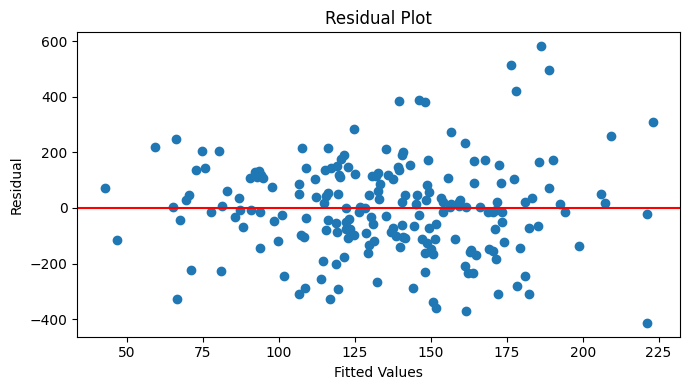

In [49]:
# Model awal
y=df["jumlah_hotspot"]
X=df[['curah_hujan', 'suhu', 'kelembapan', 'kecepatan_angin', 'luas_gambut', 'aktivitas_manusia']]

import statsmodels.api as sm
X_const = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print("=== MODEL AWAL ===")
print(model.summary())

# =========================
# DETEKSI NON-LINEARITAS
# =========================

# Nilai prediksi dan residual
fitted = model.fittedvalues
residual = model.resid

# Residual Plot
plt.figure(figsize=(7,4))

plt.scatter(fitted, residual)

plt.axhline(y=0, color='red')

plt.xlabel("Fitted Values")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.tight_layout()
plt.show()

Asumsi linearitas pada model regresi berganda telah terpenuhi karena residual menyebar secara acak di sekitar garis nol dan tidak membentuk pola tertentu. Hal ini menunjukkan bahwa hubungan antara variabel independen dan variabel dependen cenderung bersifat linear

# **9.Lakukan seleksi model untuk mendapatkan model terbaik**

In [61]:
from sklearn.metrics import mean_squared_error
def evaluasi_model(X, y):
    X_const = sm.add_constant(X)
    model = sm.OLS(y, X_const).fit()
    y_pred = model.predict(X_const)

    r2 = model.rsquared
    adj_r2 = model.rsquared_adj
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    return model, y_pred, r2, adj_r2, rmse

from itertools import combinations

# Variabel dependen
y = df['jumlah_hotspot']

# Daftar variabel independen
variabel = [
    'curah_hujan',
    'suhu',
    'kelembapan',
    'kecepatan_angin',
    'luas_gambut',
    'aktivitas_manusia'
]

# Membuat semua kombinasi model
models = {}

for r in range(1, len(variabel)+1):
    for combo in combinations(variabel, r):

        nama_model = " + ".join(combo)

        models[nama_model] = df[list(combo)]


In [62]:
hasil = []
model_objs = {}

for nama, X in models.items():
    model, _, r2, adj_r2, rmse = evaluasi_model(X, y)
    hasil.append([nama, r2, adj_r2, rmse])
    model_objs[nama] = model

hasil_data = pd.DataFrame(hasil, columns=['Model','R2','Adjusted R2','RMSE'])
hasil_data = hasil_data.sort_values(by='Adjusted R2', ascending=False)

print("===== TABEL PERBANDINGAN MODEL =====")
display(hasil_data)

best_model_name = hasil_data.iloc[0]['Model']

print("===== INTERPRETASI TABEL =====")
print(f"Model terbaik adalah: {best_model_name}")
print("Dipilih karena Adjusted R2 tertinggi dan RMSE kecil.")
print("Model sederhana lebih baik (prinsip parsimony).")

===== TABEL PERBANDINGAN MODEL =====


,Model,R2,Adjusted R2,RMSE
12,suhu + kecepatan_angin,0.036620,0.026840,169.705434
34,suhu + kecepatan_angin + luas_gambut,0.041248,0.026573,169.297342
35,suhu + kecepatan_angin + aktivitas_manusia,0.038697,0.023983,169.522440
54,suhu + kecepatan_angin + luas_gambut + aktivit...,0.043213,0.023587,169.123740
31,suhu + kelembapan + kecepatan_angin,0.037376,0.022642,169.638876
...,...,...,...,...
20,luas_gambut + aktivitas_manusia,0.009183,-0.000876,172.105054
5,aktivitas_manusia,0.002792,-0.002245,172.659285
0,curah_hujan,0.002203,-0.002837,172.710263
30,curah_hujan + luas_gambut + aktivitas_manusia,0.011909,-0.003215,171.868188


===== INTERPRETASI TABEL =====
Model terbaik adalah: suhu + kecepatan_angin
Dipilih karena Adjusted R2 tertinggi dan RMSE kecil.
Model sederhana lebih baik (prinsip parsimony).


In [53]:
model_best = model_objs[best_model_name]

print("===== RINGKASAN MODEL TERBAIK =====")
print(model_best.summary())


===== RINGKASAN MODEL TERBAIK =====
                            OLS Regression Results                            
Dep. Variable:         jumlah_hotspot   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     3.744
Date:                Wed, 27 May 2026   Prob (F-statistic):             0.0254
Time:                        13:55:41   Log-Likelihood:                -1310.6
No. Observations:                 200   AIC:                             2627.
Df Residuals:                     197   BIC:                             2637.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const 

# **10.Lakukan validasi model (train-test split) dan evaluasi hasilnya**

Variabel model terbaik:

===== HASIL EVALUASI MODEL =====
RMSE : 160.0004
MAE  : 116.6674
MAPE : 128.65%

===== SUMMARY MODEL TERBAIK =====
                            OLS Regression Results                            
Dep. Variable:         jumlah_hotspot   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     10.07
Date:                Wed, 27 May 2026   Prob (F-statistic):           7.67e-05
Time:                        14:07:53   Log-Likelihood:                -1002.1
No. Observations:                 159   AIC:                             2010.
Df Residuals:                     156   BIC:                             2019.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.02

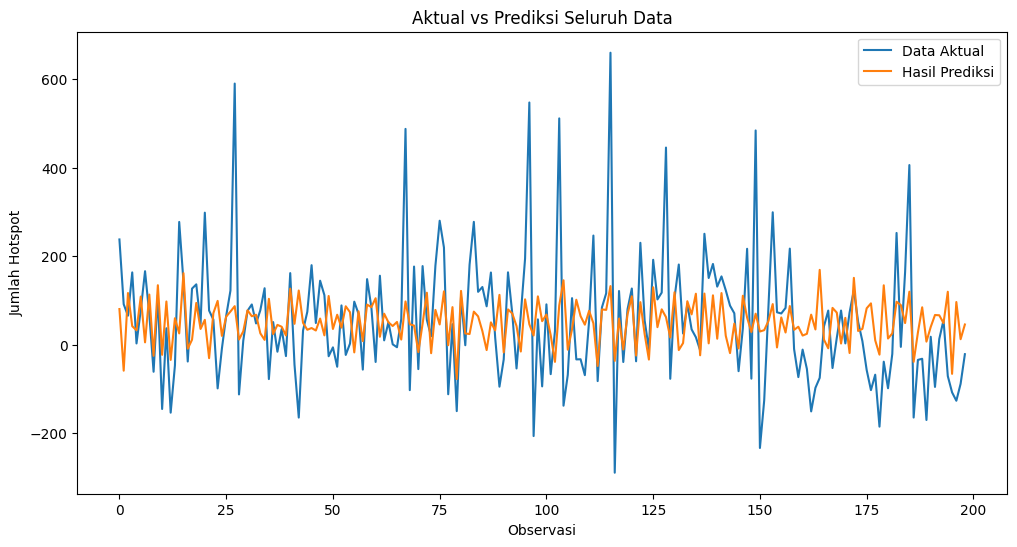

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Mengambil Model Terbaik
model_best = model_objs[best_model_name]
print("Variabel model terbaik:")
print(model_best)

# Membentuk Variabel
best_features = [feature.strip() for feature in best_model_name.split('+')]
X_best = X_CO[best_features]
y_best = y_CO

# Splitting Data
X_train, X_test, y_train, y_test = train_test_split(
    X_best,
    y_best,
    test_size=0.2,
    random_state=42
)

# Tambahkan konstanta
X_train = sm.add_constant(X_train, has_constant='add')
X_test = sm.add_constant(X_test, has_constant='add')

# Bangun Model Terbaik
final_model = sm.OLS(y_train, X_train).fit()

# Prediksi
y_pred = final_model.predict(X_test)

# Evaluasi
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("\n===== HASIL EVALUASI MODEL =====")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")

print("\n===== SUMMARY MODEL TERBAIK =====")
print(final_model.summary())

# Plot Aktual vs Prediksi
X_all = sm.add_constant(X_best, has_constant='add')
y_all_pred = final_model.predict(X_all)

plt.figure(figsize=(12,6))
plt.plot(y_best.values,
         label='Data Aktual'
         )
plt.plot(y_all_pred.values,
         label='Hasil Prediksi'
         )
plt.title('Aktual vs Prediksi Seluruh Data')
plt.xlabel('Observasi')
plt.ylabel('Jumlah Hotspot')
plt.legend()
plt.show()